# Example 1: Ruin Probability with Hyperexponential Claims
This notebook demonstrates the Talbot inversion method applied to a risk model where claim sizes follow a linear combination of exponential distributions.
In this case, the true probabilities are available.
The computed values are the ones found in the thesis.

In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import our src modules
sys.path.append(os.path.abspath('../'))

import mpmath, matplotlib.pyplot as plt
from tqdm import tqdm # for measuring progress

from src.talbot import talbot_method_abate
from src.laplace_transforms import lapl_psi, lapl_psi_1, lapl_psi_2, lapl_hyperexponential
from src.utils import print_results, get_parameters, psi_true, psi_1_true, psi_2_true

In [2]:
# Set global precision
M = 60
ctx = mpmath.mp
ctx.dps = M

## Parameter Setup
Define the parameters as in Example 1 in the thesis.

In [3]:
lmbda = ctx.mpf('1')          # Intensity of claims
c = ctx.mpf('1')              # Premium rate
sigmasq = ctx.mpf('0.4')      # Variance of diffusion term
mu = ctx.fraction('7', '12')  # Mean of claims

q = ctx.fraction('5', '12')      # Realtive security loading
zeta = 2 * c / sigmasq

In [4]:
# Range of initial capital u
u_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 10, 20, 30, 40]

## Numerical approximations

In [6]:
approx = [talbot_method_abate(lapl_psi,
                              u,
                              M=60,
                              lmbda=lmbda, # Now for the other parameters of lapl_psi
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_hyperexponential) for u in tqdm(u_values)]

approx_oscillation = [talbot_method_abate(lapl_psi_1,
                                          u,
                                          M=60,
                                          lmbda=lmbda,
                                          c=c,
                                          sigmasq=sigmasq,
                                          lapl_X_func=lapl_hyperexponential) for u in tqdm(u_values)]

approx_claim = [talbot_method_abate(lapl_psi_2,
                                    u,
                                    M=60,
                                    lmbda=lmbda, # Now for the other parameters of lapl_psi_1
                                    mu=mu,
                                    c=c,
                                    sigmasq=sigmasq,
                                    lapl_X_func=lapl_hyperexponential) for u in tqdm(u_values)]

approx_mix = [app1 + app2 for app1, app2 in zip(approx_claim, approx_oscillation)]

100%|██████████| 14/14 [00:00<00:00, 24.32it/s]


## Compute true probabilities and relative errors

In [7]:
roots, C = get_parameters(60)

true = [psi_true(u, roots, C) for u in u_values]
true_oscillation = [psi_1_true(u, roots, C, q, zeta) for u in u_values]
true_claim = [psi_2_true(u, roots, C, q, zeta) for u in u_values]

rel_error = [((approx - true) / min(true, 1 - true)) for approx, true in zip(approx, true)]
rel_error_oscillation = [((approx - true) / min(true, 1 - true)) for approx, true in zip(approx_oscillation, true_oscillation)]
rel_error_claim = [((approx - true) / min(true, 1 - true)) for approx, true in zip(approx_claim, true_claim)]
rel_error_mix = [((approx - true) / min(true, 1 - true)) for approx, true in zip(approx_mix, true)]

## Display results

In [8]:
print_results([u_values, true, approx, approx_mix], "u\tTrue Values\tApprox (direct)\tApprox (mix)", 7)
print("="*70)
print_results([u_values, rel_error, rel_error_mix, rel_error_oscillation, rel_error_claim],
              "u\tRE (direct)\tRE (mix)\tRE (noise)\tRE (claim)", 8)

u	True Values	Approx (direct)	Approx (mix)
0.1	0.8346984	0.8346984	0.8346984
0.2	0.7280872	0.7280872	0.7280872
0.3	0.6535057	0.6535057	0.6535057
0.4	0.596584	0.596584	0.596584
0.5	0.5497205	0.5497205	0.5497205
1.0	0.3786186	0.3786186	0.3786186
2.0	0.1804058	0.1804058	0.1804058
3.0	0.08579002	0.08579002	0.08579002
4.0	0.0407957	0.0407957	0.0407957
5.0	0.01939957	0.01939957	0.01939957
10.0	0.0004717157	0.0004717157	0.0004717157
20.0	2.789053e-7	2.789053e-7	2.789053e-7
30.0	1.649048e-10	1.649048e-10	1.649048e-10
40.0	9.750119e-14	9.750119e-14	9.750119e-14
u	RE (direct)	RE (mix)	RE (noise)	RE (claim)
0.1	1.1495713e-36	1.1495713e-36	5.0732936e-37	-2.3372092e-39
0.2	7.0013288e-37	7.0013288e-37	4.5605093e-37	-3.1716291e-39
0.3	5.5043298e-37	5.5043298e-37	6.2505328e-37	-4.2227507e-39
0.4	4.736211e-37	4.736211e-37	7.8834296e-37	-5.5141923e-39
0.5	4.2508813e-37	4.2508813e-37	9.3142025e-37	-7.06525e-39
1.0	5.0996636e-37	5.0996636e-37	1.4774857e-36	-1.9268024e-38
2.0	1.0877664e-36	1.0877664e-36	3.

## Show relative error for different M
We know, that the theoretical error decreases exponentially in $M$ and that the round-off error should decrease in $M$ as well.
Here we investigate the behaviour of the relative error at $u=30$.

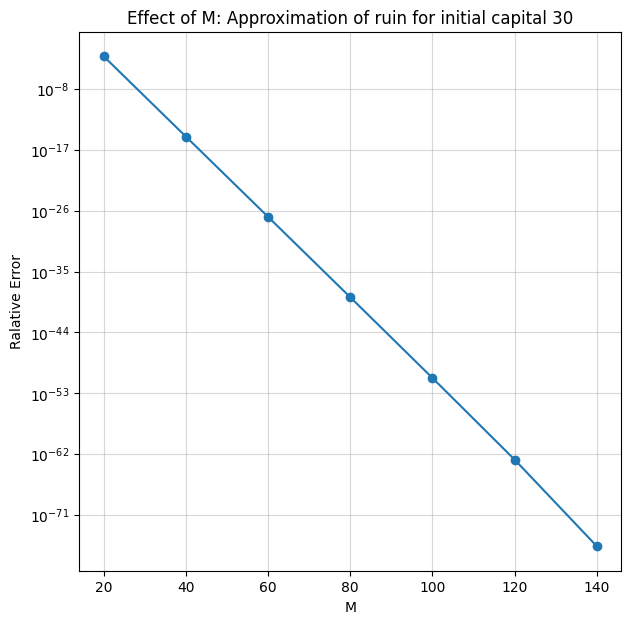

In [9]:
# Compute approximation and relative error for different values of M
Ms = [20, 40, 60, 80, 100, 120, 140]
u = 30

ctx.dps = Ms[-1] # Use largest precision we consider
roots, C = get_parameters(Ms[-1])
true_value = psi_true(u, roots, C, ctx)
approx = [talbot_method_abate(lapl_psi,
                              u,
                              M,
                              lmbda=lmbda, # Now for the other parameters of lapl_psi
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_hyperexponential) for M in Ms]

rel_error = [(abs(app - true_value) / min(true_value, 1 - true_value)) for app in approx]

plt.figure(figsize=(7, 7))
plt.semilogy(Ms, rel_error, 'o-')
plt.xlabel("M")
plt.ylabel("Ralative Error")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title(f"Effect of M: Approximation of ruin for initial capital {u}")
plt.show()

ctx.dps = M # Change back to original dps